## Loading dataset and importing Library

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('data_source/spotify_churn_dataset.csv')

## Checking the dataset for cleaning

In [7]:
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

In [9]:
df.isna().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

In [10]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [11]:
df.dtypes

user_id                    int64
gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object

In [15]:
df.duplicated().sum()

0

### No null values and no duplicated values found in the dataset. 

# EDA Analysis

In [17]:
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

## Gender Map

In [26]:
df['gender'].value_counts(normalize=True)

Male      0.336375
Female    0.332375
Other     0.331250
Name: gender, dtype: float64

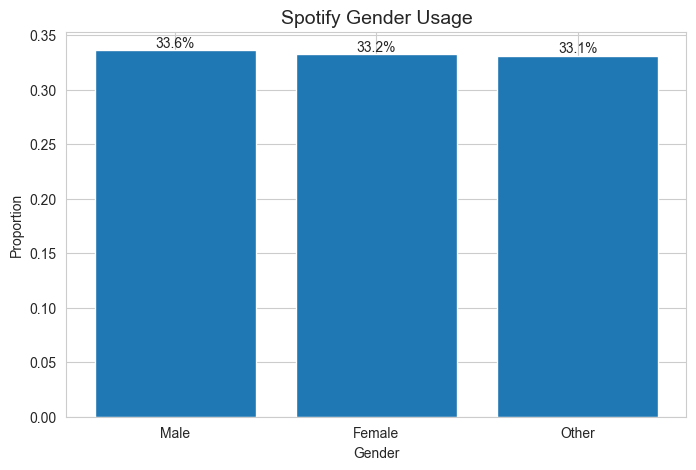

In [35]:
fig, ax = plt.subplots(figsize=(8,5))

gender_usage = df['gender'].value_counts(normalize=True)

bars = ax.bar(gender_usage.index, gender_usage.values)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.1%}',
            ha='center', va='bottom')

ax.set_title("Spotify Gender Usage", fontsize=14)
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion")

plt.show()

In [43]:
df.groupby('gender')['is_churned'].mean().sort_values(ascending=True)

gender
Male      0.251951
Other     0.261887
Female    0.262881
Name: is_churned, dtype: float64